# **STOCK PRICE PREDICTION PROJECT USING TENSORFLOW**
Stock price prediction is a challenging task in the field of finance with applications ranging from personal investment strategies to algorithmic trading. In this article we will explore how to build a stock price prediction model using TensorFlow and Long Short-Term Memory (LSTM) networks a type of recurrent neural network (RNN) which is well-suited for Timeseries data like stock prices.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
import seaborn as sns

import os
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [7]:
data = pd.read_csv('stocks_5yr.csv', delimiter=',', on_bad_lines='skip')
data

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL
...,...,...,...,...,...,...,...
619035,2018-02-01,76.84,78.27,76.69,77.82,2982259,ZTS
619036,2018-02-02,77.53,78.12,76.73,76.78,2595187,ZTS
619037,2018-02-05,76.64,76.92,73.18,73.83,2962031,ZTS
619038,2018-02-06,72.74,74.56,72.13,73.27,4924323,ZTS


In [5]:
print(data.shape)
print(data.sample(10))

(619040, 7)
              date    open      high      low   close   volume  Name
96654   2016-05-25   77.78   77.9900   76.690   76.73  3011025   CAH
271636  2013-12-06   82.43   82.7900   80.460   80.86  2295565   HES
202106  2013-09-16   66.51   66.5100   65.725   65.77  2315047  ESRX
557979  2017-03-07   72.69   73.2300   72.150   72.64  3763972   UAL
43107   2015-01-30  202.41  208.9475  202.410  205.52   551871   AMG
416526  2013-11-06   28.42   28.5900   27.890   28.16  2361888   NRG
330751  2017-01-06   42.18   42.7600   42.120   42.47  2562292  KORS
443766  2017-10-25   48.85   49.2700   48.310   49.17  2796609   PEG
424038  2013-09-09   26.17   26.4100   26.020   26.28  1961889   NWL
200688  2018-01-29   61.62   61.6771   60.760   61.21  2031024   EQR


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


Whenever we deal with the date or time feature, it should always be in the DateTime data type. Pandas library helps us convert the object date feature to the DateTime data type.

### **Loading Dataset**

In [9]:
data['date'] = pd.to_datetime(data['date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[ns]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 33.1+ MB


**This is more likely to be an 'object' data type.**

# **Exploratory Data Analysis**
Exploratory Data Analysis is a technique that is used to analyze the data through visualization and manipulation. For this project let us visualize the data of famous companies such as Nvidia, Google, Apple, Facebook and so on. First let us consider a few companies and visualize the distribution of open and closed Stock prices through 5 year

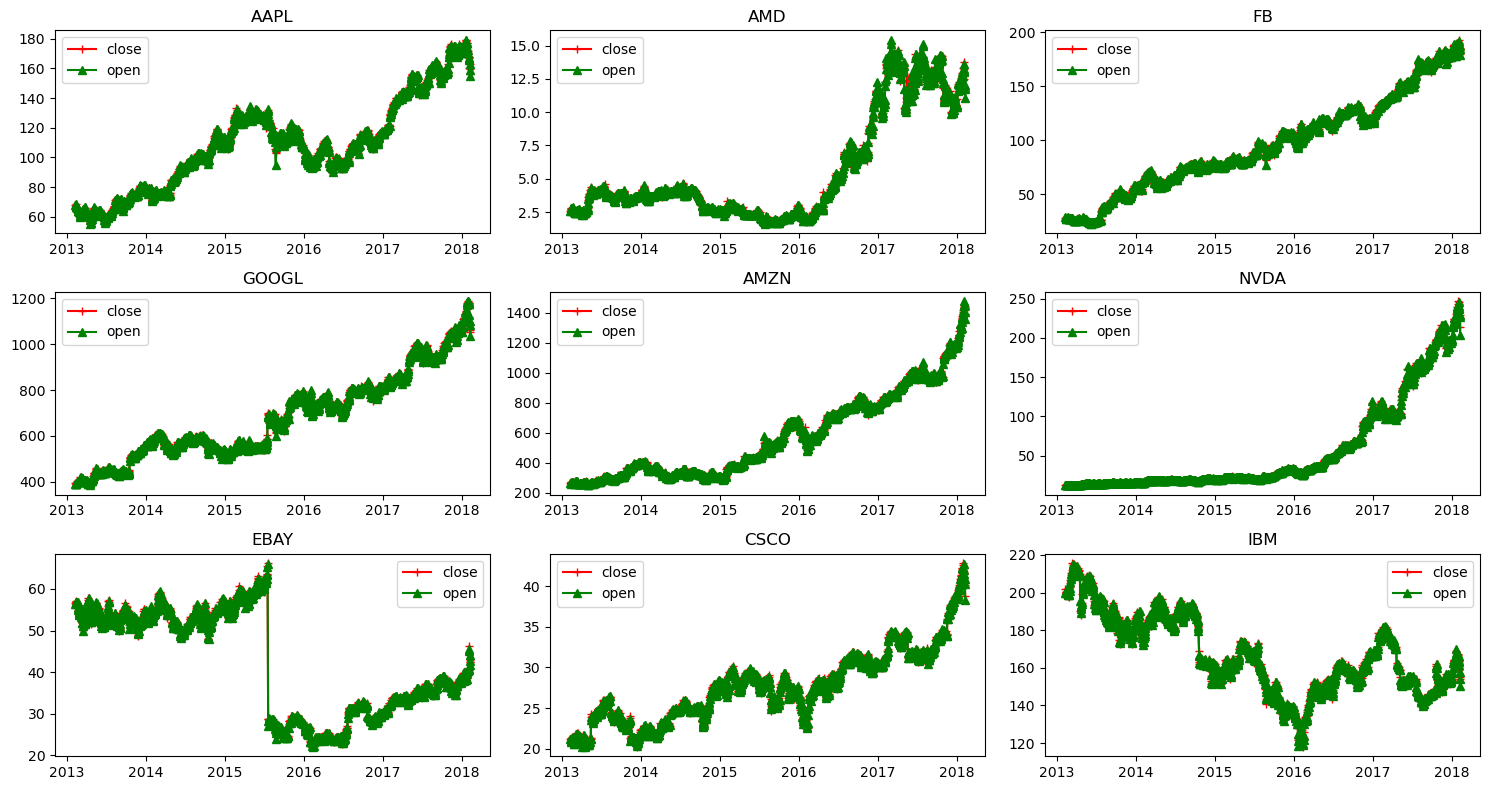

In [11]:
companies = ['AAPL', 'AMD', 'FB', 'GOOGL', 'AMZN', 'NVDA', 'EBAY', 'CSCO', 'IBM']

plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['close'], c="r", label="close", marker="+")
    plt.plot(c['date'], c['open'], c="g", label="open", marker="^")
    plt.title(company)
    plt.legend()
    plt.tight_layout()

Now let's plot the volume of trade for these 9 stocks as well as a function of time.

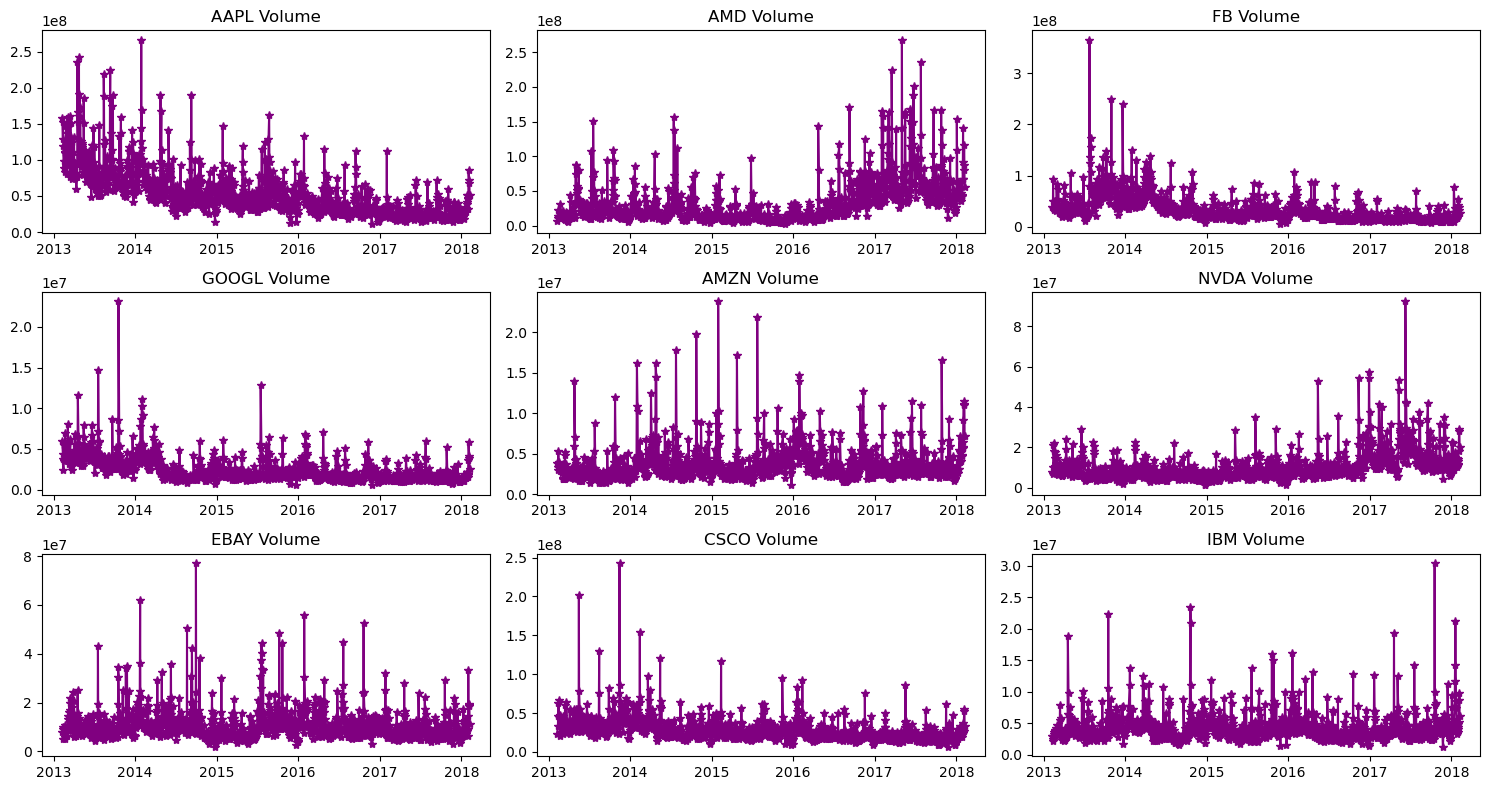

In [13]:
plt.figure(figsize=(15, 8))
for index, company in enumerate(companies, 1):
    plt.subplot(3, 3, index)
    c = data[data['Name'] == company]
    plt.plot(c['date'], c['volume'], c='purple', marker='*')
    plt.title(f"{company} Volume")
    plt.tight_layout()

Now let's analyze the data for Apple Stocks from 2013 to 2018.

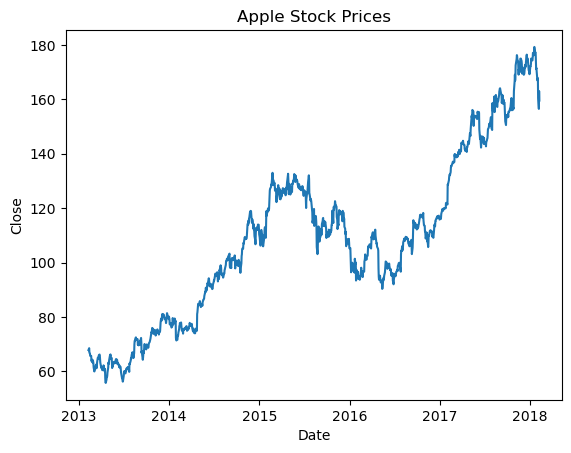

In [14]:
apple = data[data['Name'] == 'AAPL']
prediction_range = apple.loc[(apple['date'] > datetime(2013,1,1))
 & (apple['date']<datetime(2018,1,1))]
plt.plot(apple['date'],apple['close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Apple Stock Prices")
plt.show()

Now let's select a subset of the whole data as the training data so that we will be left with a subset of the data for the validation part as well.

In [15]:
close_data = apple.filter(['close'])
dataset = close_data.values
training = int(np.ceil(len(dataset) * .95))
print(training)

1197


**Now we have the training data length, next applying scaling and preparing features and labels that are x_train and y_train**

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset)

train_data = scaled_data[0:int(training), :]
# prepare feature and labels
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# **Build LSTM network using Tensorflow**
Using TensorFlow, we can easily create LSTM models. It is used in Recurrent Neural Networks for sequence models and time series data. It is used to avoid the vanishing gradient issue which is widely occurred in training RNN. To stack multiple LSTM in TensorFlow it is mandatory to use return_sequences = True. Since our data is time series varying we apply no activation to the output layer and it remains as 1 node

In [17]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(units=64,return_sequences=True,input_shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

# **Model Compilation and Training**

In [19]:
model.compile(optimizer='adam',loss='mean_squared_error')
history = model.fit(x_train,y_train,epochs=10)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - loss: 0.0220
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - loss: 0.0096
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0092
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 0.0082
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.0074
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0067
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.0063
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0068
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0069
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.0063


For predicting we require testing data, so we first create the testing data and then proceed with the model prediction.

In [20]:
test_data = scaled_data[training - 60:, :]
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

mse = np.mean(((predictions - y_test) ** 2))
rmse = np.sqrt(mse)

print("MSE", mse)
print("RMSE", np.sqrt(mse))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 790ms/step
MSE 20.27967394659153
RMSE 4.503295898182967


Now that we have predicted the testing data, let us visualize the final results

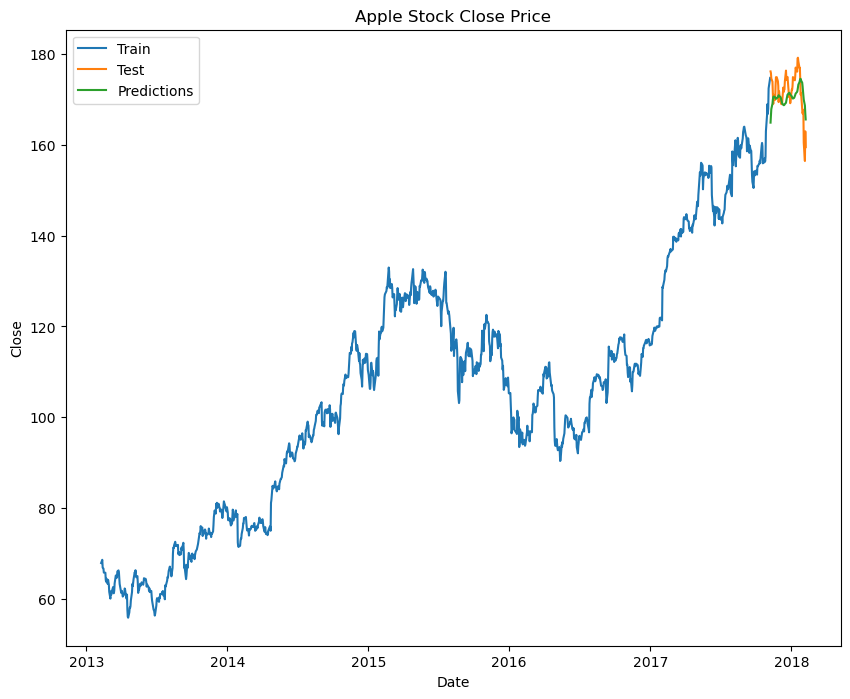

In [21]:
train = apple[:training]
test = apple[training:]
test['Predictions'] = predictions

plt.figure(figsize=(10, 8))
plt.plot(train['date'], train['close'])
plt.plot(test['date'], test[['close', 'Predictions']])
plt.title('Apple Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])

The chart shows Apple’s stock closing price over time with the "Train" data representing historical prices used for model training, "Test" data for evaluation and "Predictions" showing the model’s forecasted values.